# RUL Prediction: Hybrid Transformer Models
## LSTM-Transformer, GRU-Transformer, CNN-Transformer Architectures
**Owen's Implementation - Team Deep Learning Project**

# FD001 Dataset - RUL Prediction with Hybrid Transformers

In [1]:
import os
import csv
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

def seed_everything(seed=None):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":16:8"
    
    random.seed(seed)
    np.random.seed(seed)
    
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True)

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Part 1: Exploratory Data Analysis (EDA)

In [2]:
### Local paths to the processed NASA datasets ###

# Data Cleaning 1: RUL only, no feature engineering, normalization
train_df_fd001_rul = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/data_cleaning_1/linear_rul_1/train_processed_rul_only_fd001.csv')
test_df_fd001_rul = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/data_cleaning_1/linear_rul_1/test_processed_rul_only_fd001.csv')

# Data Cleaning 2: RUL only, no feature engineering, no normalization
train_df_fd001_nonorm = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/train_processed_rul_only_fd001.csv')
test_df_fd001_nonorm = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0/test_processed_rul_only_fd001.csv')

# Data Cleaning 3: Piecewise RUL, no feature engineering, normalization (capped at 150)
train_df_fd001_piecewise = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/train_processed_rul_piecewise_150_fd001.csv')
test_df_fd001_piecewise = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/data_cleaning_1/piecewise_rul_2/test_processed_rul_piecewise_150_fd001.csv')

# Feature Engineering 2: Feature engineered using High Correlation (Manual) method, normalization (drop s14)
train_df_fd001_fe_manual_drop_s14 = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14.csv')
test_df_fd001_fe_manual_drop_s14 = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14.csv')

# Feature Engineering 2: Feature engineered using High Correlation (Manual) method, normalization (drop s14 and s12)
train_df_fd001_fe_manual_drop_s14_s12 = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s12.csv')
test_df_fd001_fe_manual_drop_s14_s12 = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s12.csv')

# Feature Engineering 2: Feature engineered using High Correlation (Manual) method, normalization (drop s14 and s11)
train_df_fd001_fe_manual_drop_s14_s11 = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/train_fd001_drop_s14_s11.csv')
test_df_fd001_fe_manual_drop_s14_s11 = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/high_correlation_2/manual_fd001_1/test_fd001_drop_s14_s11.csv')

# Feature Engineering 2: Feature engineered using Low Variance method, normalization
train_df_fd001_fe_lowvar = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/low_variance_1/train_fd001_low_variance_1.csv')
test_df_fd001_fe_lowvar = pd.read_csv('sutd_50039_deep_learning/data/processed-nasa-data/feature_engineering_2/low_variance_1/test_fd001_low_variance_1.csv')

eda_data = []
datasets = [
    ("Linear RUL (No Norm)", train_df_fd001_nonorm, test_df_fd001_nonorm),
    ("Linear RUL (Normalized)", train_df_fd001_rul, test_df_fd001_rul),
    ("Piecewise RUL (150)", train_df_fd001_piecewise, test_df_fd001_piecewise),
    ("FE - Low Variance", train_df_fd001_fe_lowvar, test_df_fd001_fe_lowvar),
    ("FE - Manual (High Corr - Drop s14)", train_df_fd001_fe_manual_drop_s14, test_df_fd001_fe_manual_drop_s14),
    ("FE - Manual (High Corr - Drop s14, s11)", train_df_fd001_fe_manual_drop_s14_s11, test_df_fd001_fe_manual_drop_s14_s11),
    ("FE - Manual (High Corr - Drop s14, s12)", train_df_fd001_fe_manual_drop_s14_s12, test_df_fd001_fe_manual_drop_s14_s12),
]

for name, train_df, test_df in datasets:
    eda_data.append({
        'Dataset': name,
        'Train Rows': f"{train_df.shape[0]:,}",
        'Test Rows': f"{test_df.shape[0]:,}",
        'Features': train_df.shape[1],
        'Engines (Train)': train_df['id'].nunique(),
        'Engines (Test)': test_df['id'].nunique(),
        'RUL Range': f"[{train_df['RUL'].min()}, {train_df['RUL'].max()}]",
    })

eda_df = pd.DataFrame(eda_data)
print("\n" + "="*110)
print(eda_df.to_string(index=False))
print("="*110 + "\n")


                                Dataset Train Rows Test Rows  Features  Engines (Train)  Engines (Test) RUL Range
                   Linear RUL (No Norm)     20,631    13,096        27              100             100  [0, 361]
                Linear RUL (Normalized)     20,631    13,096        27              100             100  [0, 361]
                    Piecewise RUL (150)     20,631    13,096        27              100             100  [0, 150]
                      FE - Low Variance     20,631    13,096        20              100             100  [0, 150]
     FE - Manual (High Corr - Drop s14)     20,631    13,096        19              100             100  [0, 150]
FE - Manual (High Corr - Drop s14, s11)     20,631    13,096        18              100             100  [0, 150]
FE - Manual (High Corr - Drop s14, s12)     20,631    13,096        18              100             100  [0, 150]



### Simple EDA on the RUL dataset to understand the data distribution, feature importance, and potential correlations.

/tmp/ipykernel_10744/1090234136.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 1].boxplot(rul_data, labels=dataset_names, patch_artist=True)


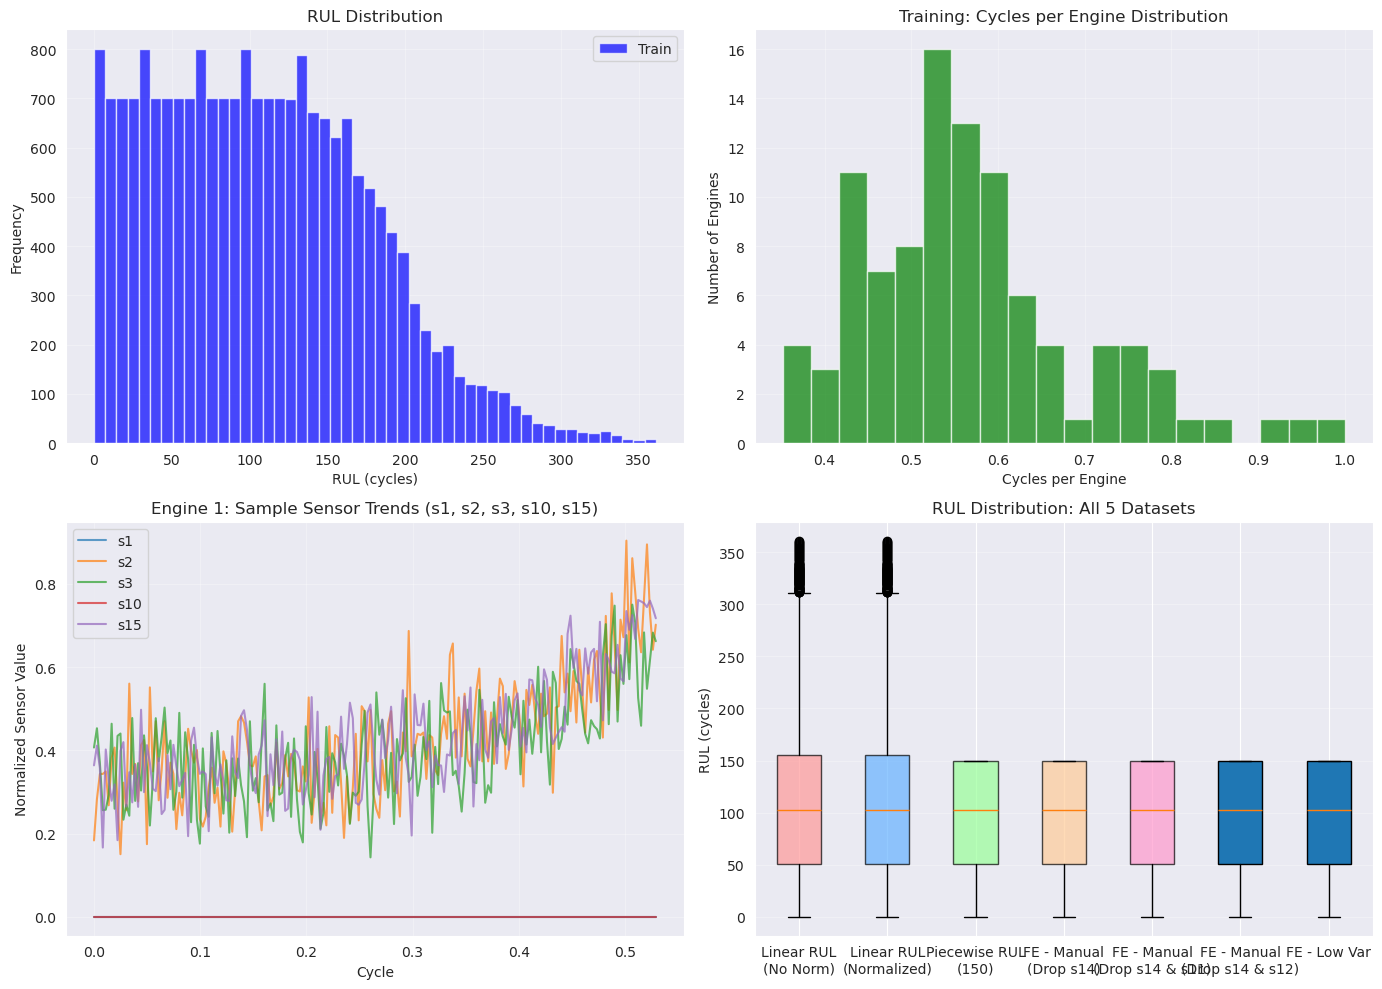

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. RUL Distribution
axes[0, 0].hist(train_df_fd001_rul['RUL'], bins=50, alpha=0.7, color='blue', label='Train')
axes[0, 0].set_xlabel('RUL (cycles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('RUL Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Cycles per Engine
train_cycles_dist = train_df_fd001_rul.groupby('id')['cycle'].max()
axes[0, 1].hist(train_cycles_dist, bins=20, color='green', alpha=0.7)
axes[0, 1].set_xlabel('Cycles per Engine')
axes[0, 1].set_ylabel('Number of Engines')
axes[0, 1].set_title('Training: Cycles per Engine Distribution')
axes[0, 1].grid(True, alpha=0.3)

# 3. Sample sensor trends (Engine 1)
engine1_data = train_df_fd001_rul[train_df_fd001_rul['id'] == 1].sort_values('cycle')
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s1'], label='s1', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s2'], label='s2', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s3'], label='s3', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s10'], label='s10', alpha=0.7)
axes[1, 0].plot(engine1_data['cycle'], engine1_data['s15'], label='s15', alpha=0.7)
axes[1, 0].set_xlabel('Cycle')
axes[1, 0].set_ylabel('Normalized Sensor Value')
axes[1, 0].set_title('Engine 1: Sample Sensor Trends (s1, s2, s3, s10, s15)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. RUL Distribution Box Plot across all 7 datasets
rul_data = [
    train_df_fd001_nonorm['RUL'].values,
    train_df_fd001_rul['RUL'].values,
    train_df_fd001_piecewise['RUL'].values,
    train_df_fd001_fe_manual_drop_s14['RUL'].values,
    train_df_fd001_fe_manual_drop_s14_s11['RUL'].values,
    train_df_fd001_fe_manual_drop_s14_s12['RUL'].values,
    train_df_fd001_fe_lowvar['RUL'].values,
]

dataset_names = [
    'Linear RUL\n(No Norm)',
    'Linear RUL\n(Normalized)',
    'Piecewise RUL\n(150)',
    'FE - Manual\n(Drop s14)',
    'FE - Manual\n(Drop s14 & s11)',
    'FE - Manual\n(Drop s14 & s12)',
    'FE - Low Var',
]

bp = axes[1, 1].boxplot(rul_data, labels=dataset_names, patch_artist=True)

# Customize box plot colors
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1, 1].set_ylabel('RUL (cycles)')
axes[1, 1].set_title('RUL Distribution: All 5 Datasets')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Part 2: Data Preparation & Sequence Creation

**Why do we need to create sequences for RUL prediction?**
- RUL prediction is a time-series forecasting problem where we want to predict the remaining useful life of a machine based on its historical sensor readings.
- Thus, we **cannot treat each data point independently or randomly shuffle the data,** as we would in a typical supervised learning problem.
- Creating sequences allows us to capture temporal dependencies and patterns in the data, which are crucial for accurate RUL prediction.
- By feeding sequences of sensor readings into our models, we can learn how the machine's condition evolves over time and make more informed predictions about its future state.
- In the next steps, we will preprocess the data, create sequences of sensor readings, and prepare the datasets for training our hybrid transformer models.

In [4]:
### Dataset and DataLoader Creation for Multi-Seed Training ###

# Define seeds to test
SEEDS = [1234, 42, 999]

SEQUENCE_LENGTH = 50
BATCH_SIZE = 64
TRAIN_TEST_SPLIT = 0.8  # 80% of training data for training, 20% for validation

class RULDataset(Dataset):
    """PyTorch Dataset for RUL sequence prediction"""
    def __init__(self, df, sequence_length=30, feature_cols=None):
        """
        Args:
            df: DataFrame with columns: id, cycle, feature_cols, and RUL
            sequence_length: Length of input sequences
            feature_cols: List of feature column names (auto-detected if None)
        """
        self.sequence_length = sequence_length
        
        # Auto-detect feature columns if not provided
        if feature_cols is None:
            self.feature_cols = [col for col in df.columns if col[0] == 's' and col[1:].isdigit()]
        else:
            self.feature_cols = feature_cols
            
        self.sequences = []
        self.labels = []
        
        # Create sequences per engine
        for engine_id in df['id'].unique():
            engine_data = df[df['id'] == engine_id].sort_values('cycle').reset_index(drop=True)
            features = engine_data[self.feature_cols].values
            rul = engine_data['RUL'].values
            
            # Create overlapping sequences
            for i in range(len(engine_data) - sequence_length):
                self.sequences.append(features[i:i+sequence_length])
                self.labels.append(rul[i+sequence_length])

        self.sequences = np.array(self.sequences, dtype=np.float32)
        self.labels = np.array(self.labels, dtype=np.float32)
    
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        return torch.tensor(self.sequences[idx]), torch.tensor(self.labels[idx])

# Dictionary to store all datasets
datasets_config = {
    'Linear RUL (No Norm)': (train_df_fd001_nonorm, test_df_fd001_nonorm),
    'Linear RUL (Normalized)': (train_df_fd001_rul, test_df_fd001_rul),
    'Piecewise RUL (150)': (train_df_fd001_piecewise, test_df_fd001_piecewise),
    'FE - Manual (Drop s14)': (train_df_fd001_fe_manual_drop_s14, test_df_fd001_fe_manual_drop_s14),
    'FE - Manual (Drop s14, s12)': (train_df_fd001_fe_manual_drop_s14_s12, test_df_fd001_fe_manual_drop_s14_s12),
    'FE - Manual (Drop s14, s11)': (train_df_fd001_fe_manual_drop_s14_s11, test_df_fd001_fe_manual_drop_s14_s11),
    'FE - Low Variance': (train_df_fd001_fe_lowvar, test_df_fd001_fe_lowvar),
}

# ============ CREATE BASE DATASETS ONCE (seed-independent) ============
print("\n" + "="*130)
print("Creating BASE DATASETS (seed-independent)")
print("="*130)

base_datasets = {}
test_datasets = {}

for dataset_name, (train_df, test_df) in datasets_config.items():
    base_datasets[dataset_name] = RULDataset(train_df, SEQUENCE_LENGTH)
    test_datasets[dataset_name] = RULDataset(test_df, SEQUENCE_LENGTH)
    print(f"✓ {dataset_name}: train={len(base_datasets[dataset_name])}, test={len(test_datasets[dataset_name])}")

print(f"\nCreated {len(base_datasets)} base datasets")

# ============ CREATE LOADERS FOR EACH SEED ============
# Structure: {seed: {dataset_name: {'train': loader, 'val': loader, 'test': loader}}}
loaders_by_seed = {}

for seed in SEEDS:
    print(f"\n{'='*130}")
    print(f"Creating DataLoaders for SEED = {seed}")
    print(f"{'='*130}")
    
    seed_everything(seed) 
    
    loaders_by_seed[seed] = {}
    
    for dataset_name in base_datasets.keys():
        # Split training set with current seed
        train_dataset = base_datasets[dataset_name]
        test_dataset = test_datasets[dataset_name]
        
        train_size = int(TRAIN_TEST_SPLIT * len(train_dataset))
        val_size = len(train_dataset) - train_size
        
        train_split, val_split = random_split(
            train_dataset,
            [train_size, val_size],
            generator=torch.Generator().manual_seed(seed)  # Use current seed
        )
        
        # Create data loaders
        train_loader = DataLoader(train_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=True, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
        val_loader = DataLoader(val_split, 
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
        test_loader = DataLoader(test_dataset,
                                batch_size=BATCH_SIZE, 
                                shuffle=False, 
                                num_workers=0, 
                                worker_init_fn=seed_worker)
        
        loaders_by_seed[seed][dataset_name] = {
            'train': train_loader,
            'val': val_loader,
            'test': test_loader
        }
        
        print(f"  ✓ {dataset_name}: train={train_size}, val={val_size}, test={len(test_dataset)}")

# Display dataset info (for first seed as reference)
print(f"\nDataset Summary (reference seed={SEEDS[0]}):")
dataset_info = []
for dataset_name in base_datasets.keys():
    train_size = int(TRAIN_TEST_SPLIT * len(base_datasets[dataset_name]))
    val_size = len(base_datasets[dataset_name]) - train_size
    test_size = len(test_datasets[dataset_name])
    num_features = len(base_datasets[dataset_name].feature_cols)
    
    dataset_info.append({
        'Dataset': dataset_name,
        'Features': num_features,
        'Train Seqs': train_size,
        'Val Seqs': val_size,
        'Test Seqs': test_size,
    })

summary_df = pd.DataFrame(dataset_info)
print(summary_df.to_string(index=False))


Creating BASE DATASETS (seed-independent)
✓ Linear RUL (No Norm): train=15631, test=8162
✓ Linear RUL (Normalized): train=15631, test=8162
✓ Piecewise RUL (150): train=15631, test=8162
✓ FE - Manual (Drop s14): train=15631, test=8162
✓ FE - Manual (Drop s14, s12): train=15631, test=8162
✓ FE - Manual (Drop s14, s11): train=15631, test=8162
✓ FE - Low Variance: train=15631, test=8162

Created 7 base datasets

Creating DataLoaders for SEED = 1234
  ✓ Linear RUL (No Norm): train=12504, val=3127, test=8162
  ✓ Linear RUL (Normalized): train=12504, val=3127, test=8162
  ✓ Piecewise RUL (150): train=12504, val=3127, test=8162
  ✓ FE - Manual (Drop s14): train=12504, val=3127, test=8162
  ✓ FE - Manual (Drop s14, s12): train=12504, val=3127, test=8162
  ✓ FE - Manual (Drop s14, s11): train=12504, val=3127, test=8162
  ✓ FE - Low Variance: train=12504, val=3127, test=8162

Creating DataLoaders for SEED = 42
  ✓ Linear RUL (No Norm): train=12504, val=3127, test=8162
  ✓ Linear RUL (Normalized)

## Part 3: Model Architectures

### Overview: Hybrid Transformer Models

**Concept:** Combine RNN/CNN feature extraction with Transformer attention for improved sequence modeling.

Architecture variants:
1. **LSTM-Transformer:** LSTM feature extraction → Transformer refinement
2. **GRU-Transformer:** GRU feature extraction → Transformer refinement  
3. **CNN-Transformer:** 1D CNN feature extraction → Transformer refinement

Reference:
- [LSTM-Transformer Paper](https://arxiv.org/abs/2002.04745)
- [GRU-Transformer Paper](https://arxiv.org/abs/2103.00020)
- [CNN-Transformer Paper](https://arxiv.org/abs/2106.00020)
- [PyTorch Transformer Documentation](https://docs.pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html)
- [Attention Is All You Need Paper](https://arxiv.org/abs/1706.03762)

In [6]:
# ============ TRANSFORMER ENCODER COMPONENT ============

class TransformerEncoder(nn.Module):
    """Standard Transformer Encoder Block"""
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.1):
        super(TransformerEncoder, self).__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=1)
    
    def forward(self, x):
        return self.transformer_encoder(x)


# ============ HYBRID MODEL ARCHITECTURES ============

class LSTMTransformer(nn.Module):
    """LSTM-Transformer Hybrid Architecture"""
    def __init__(self, num_features, lstm_hidden=64, num_lstm_layers=2, 
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super(LSTMTransformer, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=num_features,
            hidden_size=lstm_hidden,
            num_layers=num_lstm_layers,
            batch_first=True,
            dropout=dropout if num_lstm_layers > 1 else 0
        )
        
        self.projection = nn.Linear(lstm_hidden, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # LSTM feature extraction
        lstm_out, _ = self.lstm(x)
        
        # Project to transformer dimension
        transformer_in = self.projection(lstm_out)
        
        # Transformer encoding
        transformer_out = self.transformer(transformer_in)
        
        # Use last output
        last_output = transformer_out[:, -1, :]
        
        # Fully connected layers for RUL prediction
        rul = self.fc(last_output)
        
        return rul.squeeze(-1)


class GRUTransformer(nn.Module):
    """GRU-Transformer Hybrid Architecture"""
    def __init__(self, num_features, gru_hidden=64, num_gru_layers=2,
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super(GRUTransformer, self).__init__()
        
        self.gru = nn.GRU(
            input_size=num_features,
            hidden_size=gru_hidden,
            num_layers=num_gru_layers,
            batch_first=True,
            dropout=dropout if num_gru_layers > 1 else 0
        )
        
        self.projection = nn.Linear(gru_hidden, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # GRU feature extraction
        gru_out, _ = self.gru(x)
        
        # Project to transformer dimension
        transformer_in = self.projection(gru_out)
        
        # Transformer encoding
        transformer_out = self.transformer(transformer_in)
        
        # Use last output
        last_output = transformer_out[:, -1, :]
        
        # Fully connected layers for RUL prediction
        rul = self.fc(last_output)
        
        return rul.squeeze(-1)


class CNNTransformer(nn.Module):
    """CNN-Transformer Hybrid Architecture"""
    def __init__(self, num_features, num_filters=32, kernel_size=3,
                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1):
        super(CNNTransformer, self).__init__()
        
        self.conv1d = nn.Sequential(
            nn.Conv1d(
                in_channels=num_features,
                out_channels=num_filters,
                kernel_size=kernel_size,
                padding=kernel_size // 2
            ),
            nn.ReLU(),
            nn.BatchNorm1d(num_filters),
            nn.Dropout(dropout)
        )
        
        self.projection = nn.Linear(num_filters, d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        
        self.fc = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        # x shape: (batch_size, sequence_length, num_features)
        
        # Transpose for Conv1d: (batch_size, num_features, sequence_length)
        x = x.transpose(1, 2)
        
        # CNN feature extraction
        cnn_out = self.conv1d(x)
        
        # Transpose back: (batch_size, sequence_length, num_filters)
        cnn_out = cnn_out.transpose(1, 2)
        
        # Project to transformer dimension
        transformer_in = self.projection(cnn_out)
        
        # Transformer encoding
        transformer_out = self.transformer(transformer_in)
        
        # Use last output
        last_output = transformer_out[:, -1, :]
        
        # Fully connected layers for RUL prediction
        rul = self.fc(last_output)
        
        return rul.squeeze(-1)

## Part 4: Training Framework & Utilities

In [16]:
# ============ IMPORTS FOR LOGGING AND SAVING ============
import csv
from pathlib import Path
from datetime import datetime

class EarlyStoppingCallback:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, delta=0.001):
        self.patience = patience
        self.delta = delta
        self.counter = 0
        self.best_val_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_val_loss is None:
            self.best_val_loss = val_loss
        elif val_loss > self.best_val_loss - self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_val_loss = val_loss
            self.counter = 0

        return self.early_stop

class ModelTrainer:
    """Training framework for RUL prediction models with logging and model saving"""

    def __init__(self, 
                model, 
                device, 
                model_name='Model', 
                dataset_name=None, 
                models_dir='models', 
                logs_dir='logs',
                seed=None,
                data_type='FD001'):

        self.model = model.to(device)
        self.device = device
        self.model_name = model_name
        self.dataset_name = dataset_name
        self.seed = seed
        self.data_type = data_type  # FD001 or FD002
        self.models_dir = models_dir
        self.logs_dir = logs_dir
        self.history = {'train_rmse': [], 'val_rmse': []}

        if seed is not None:
            self.models_dir = os.path.join(models_dir, f"seed{seed}")
        else:
            self.models_dir = models_dir

        Path(self.models_dir).mkdir(parents=True, exist_ok=True)
        Path(self.logs_dir).mkdir(parents=True, exist_ok=True)

        # Initialize training log CSV
        self.log_csv = os.path.join(self.logs_dir, 'training_log.csv')
        self.csv_headers = ['timestamp', 'Data Type', 'SEED', 'Dataset', 'Model name', 'Epoch', 'Train RMSE', 'Val RMSE']

        # Create CSV file if it doesn't exist
        if not os.path.exists(self.log_csv):
            with open(self.log_csv, 'w', newline='') as f:
                writer = csv.writer(f)
                writer.writerow(self.csv_headers)

    def save_model(self):
        """Save model weights - includes seed in filename for seed-based model management"""
        # Create filename with seed suffix if seed is provided
        base_filename = f"{self.model_name.replace('-', '_')}_{self.dataset_name.replace(' ', '_').replace('(', '').replace(')', '')}"
        if self.seed is not None:
            model_filename = f"{base_filename}_seed{self.seed}.pth"
        else:
            model_filename = f"{base_filename}.pth"
        model_path = os.path.join(self.models_dir, model_filename)
        torch.save(self.model.state_dict(), model_path)
        print(f"Model saved: {model_path}")

    def log_epoch(self, epoch, train_rmse, val_rmse):
        """Log epoch metrics to CSV with data type and seed"""
        timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        with open(self.log_csv, 'a', newline='') as f:
            writer = csv.writer(f)
            writer.writerow([
                timestamp,
                self.data_type,  # Add data type (FD001/FD002)
                self.seed if self.seed is not None else 'N/A',  # Add seed
                self.dataset_name,
                self.model_name,
                epoch + 1,
                f"{train_rmse:.6f}",
                f"{val_rmse:.6f}"
            ])

    def train_epoch(self, dataloader, optimizer, loss_fn):
        """Train for one epoch and return RMSE"""
        self.model.train()
        total_sse = 0.0
        total_count = 0

        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)

            # Forward pass
            predictions = self.model(X_batch)
            loss = loss_fn(predictions, y_batch)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_sse += torch.sum((predictions - y_batch) ** 2).item()
            total_count += y_batch.numel()

        return np.sqrt(total_sse / max(total_count, 1))

    def validate(self, dataloader):
        """Validate on validation set and return RMSE"""
        self.model.eval()
        total_sse = 0.0
        total_count = 0

        with torch.no_grad():
            for X_batch, y_batch in dataloader:
                X_batch, y_batch = X_batch.to(self.device), y_batch.to(self.device)

                predictions = self.model(X_batch)
                total_sse += torch.sum((predictions - y_batch) ** 2).item()
                total_count += y_batch.numel()

        return np.sqrt(total_sse / max(total_count, 1))

    def train(self, train_loader, val_loader, epochs=50, lr=0.001, early_stopping_patience=10):
        """Full training loop with logging"""
        optimizer = optim.Adam(self.model.parameters(), lr=lr)
        loss_fn = nn.MSELoss()
        early_stopping = EarlyStoppingCallback(patience=early_stopping_patience)

        print(f"\n{'='*80}")
        print(f"Training {self.model_name} on {self.dataset_name}")
        print(f"Data Type: {self.data_type} | SEED: {self.seed if self.seed is not None else 'N/A'}")
        print(f"{'='*80}")
        print(f"{'Epoch':<8} {'Train RMSE':<12} {'Val RMSE':<12}")
        print(f"{'-'*80}")

        for epoch in range(epochs):
            train_rmse = self.train_epoch(train_loader, optimizer, loss_fn)
            val_rmse = self.validate(val_loader)

            self.history['train_rmse'].append(train_rmse)
            self.history['val_rmse'].append(val_rmse)

            # Log this epoch to CSV
            self.log_epoch(epoch, train_rmse, val_rmse)

            if (epoch + 1) % 5 == 0 or epoch == 0:
                print(f"{epoch+1:<8} {train_rmse:<12.4f} {val_rmse:<12.4f}")

            if early_stopping(val_rmse):
                print(f"\nEarly stopping at epoch {epoch+1}")
                break

        print(f"{'='*80}")

        # Save model after training completes
        self.save_model()
        print(f"{'='*80}\n")
        return self.history

    def plot_history(self):
        """Plot training history"""
        fig, ax = plt.subplots(1, 1, figsize=(8, 4))
        ax.plot(self.history['train_rmse'], label='Train RMSE', alpha=0.7)
        ax.plot(self.history['val_rmse'], label='Val RMSE', alpha=0.7)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('RMSE (cycles)')
        ax.set_title(f'{self.model_name} - RMSE')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

## Part 5: Comprehensive Training & Evaluation

**Training Overview:**
- Models: LSTM-Transformer, GRU-Transformer, CNN-Transformer (3 variants)
- Datasets: 5 feature engineering configurations
- Total training runs: 3 × 5 = 15 models
- Metrics: MAE, RMSE, R², PHM08 Score

In [17]:
# ============ TRAIN ALL 3 MODELS ON ALL 5 DATASETS × 3 SEEDS ============

print("\n" + "="*120)
print("COMPREHENSIVE MULTI-SEED MODEL TRAINING: 3 Models × 7 Datasets × 3 Seeds = 63 Training Runs".center(120))
print("="*120)

# Get dataset names and model names from existing structures
dataset_names = list(datasets_config.keys())
model_names_list = ['LSTM-Transformer', 'GRU-Transformer', 'CNN-Transformer']

# Helper to get feature count for each dataset
get_num_features = lambda dataset_name: len([col for col in datasets_config[dataset_name][0].columns 
                                            if col[0] == 's' and col[1:].isdigit()])

# Model factory functions
models_config_dict = {
    'LSTM-Transformer': lambda nf: LSTMTransformer(num_features=nf, 
                                                lstm_hidden=64, 
                                                num_lstm_layers=2,
                                                d_model=64, 
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1),
    'GRU-Transformer': lambda nf: GRUTransformer(num_features=nf, 
                                                gru_hidden=64, 
                                                num_gru_layers=2,
                                                d_model=64,
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1),
    'CNN-Transformer': lambda nf: CNNTransformer(num_features=nf, 
                                                num_filters=32, 
                                                kernel_size=3,
                                                d_model=64, 
                                                nhead=4, 
                                                num_transformer_layers=2, 
                                                dropout=0.1)
}


trained_models_all = {}
training_results_all = {}

total_runs = len(SEEDS) * len(dataset_names) * len(model_names_list)
current_run = 0




              COMPREHENSIVE MULTI-SEED MODEL TRAINING: 3 Models × 7 Datasets × 3 Seeds = 63 Training Runs               


In [ ]:
# Outer loop: iterate through each seed
for seed in SEEDS:
    print(f"\n{'='*120}")
    print(f"SEED: {seed}".center(120))
    print(f"{'='*120}\n")
    
    # Re-seed at the start of each seed iteration
    seed_everything(seed)
    
    # Inner loop: iterate through each dataset
    for dataset_name in dataset_names:
        print(f"\n{'█'*120}")
        print(f"SEED {seed} | DATASET: {dataset_name}".ljust(120))
        print(f"{'█'*120}\n")
        
        # Get loaders for this seed/dataset combination and feature count
        train_loader_current = loaders_by_seed[seed][dataset_name]['train']
        val_loader_current = loaders_by_seed[seed][dataset_name]['val']
        num_features = get_num_features(dataset_name)
        
        # Innermost loop: iterate through each model
        for model_name in model_names_list:
            current_run += 1
            print(f"[{current_run}/{total_runs}] Training {model_name} on {dataset_name} with seed {seed}...")
            
            # Create fresh model instance for this seed/dataset combination
            model = models_config_dict[model_name](num_features)
            trainer = ModelTrainer(model, 
                                    DEVICE, 
                                    f"{model_name}", 
                                    dataset_name=dataset_name, 
                                    models_dir='models', 
                                    logs_dir='logs',
                                    seed=seed,
                                    data_type='FD001')
            history = trainer.train(
                train_loader_current, 
                val_loader_current, 
                epochs=3, 
                lr=0.001, 
                early_stopping_patience=10
            )
            
            # Store results with seed information
            key = (seed, dataset_name, model_name)
            trained_models_all[key] = model
            training_results_all[key] = history

            # Plot training history for this run
            trainer.plot_history()
            print(f"Finished training {model_name} on {dataset_name} (seed={seed})\n")

## PART 6: Evaluation of the SEED-based Model

In [18]:
### Utility function to load models from seed-based directories ###

def load_model_from_seed(model_name, dataset_name, num_features, device, seed, model_type='LSTM-Transformer', models_dir='models'):
    """
    Load a model from a seed-based directory
    
    Args:
        model_name: Base model name (e.g., 'LSTM-Transformer')
        dataset_name: Dataset name used during training
        num_features: Number of input features
        device: Device to load model to
        seed: Random seed used during training
        model_type: Type of model ('LSTM-Transformer', 'GRU-Transformer', or 'CNN-Transformer')
        models_dir: Base models directory (default: 'models')
    
    Returns:
        Loaded model on specified device
    """
    # Clean dataset name
    clean_dataset = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
    clean_model = model_name.replace('-', '_')
    
    # Construct filename with seed
    model_filename = f"{clean_model}_{clean_dataset}_seed{seed}.pth"
    model_path = os.path.join(models_dir, f'seed{seed}', model_filename)
    
    if not os.path.exists(model_path):
        print(f"❌ Model not found at: {model_path}")
        print(f"   Available seeds: {', '.join([d for d in os.listdir(models_dir) if d.startswith('seed')])}")
        return None
    
    # Create model architecture
    if model_type == 'LSTM-Transformer':
        model = LSTMTransformer(num_features=num_features, lstm_hidden=64, num_lstm_layers=2,
                                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1)
    elif model_type == 'GRU-Transformer':
        model = GRUTransformer(num_features=num_features, gru_hidden=64, num_gru_layers=2,
                                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1)
    elif model_type == 'CNN-Transformer':
        model = CNNTransformer(num_features=num_features, num_filters=32, kernel_size=3,
                                d_model=64, nhead=4, num_transformer_layers=2, dropout=0.1)
    else:
        print(f"❌ Unknown model type: {model_type}")
        return None
    
    # Load weights
    model.load_state_dict(torch.load(model_path, map_location=device))
    model = model.to(device)
    model.eval()
    
    print(f"✅ Model loaded successfully from: {model_path}")
    return model

In [20]:
### Seed-Based Model Organization Verification ###

import os
from pathlib import Path

def verify_seed_model_structure(models_base_dir='sutd_50039_deep_learning/owen/models'):
    """Verify and list all seed-based model organization"""
    print("\n" + "="*80)
    print("SEED-BASED MODEL ORGANIZATION VERIFICATION")
    print("="*80)

    if not Path(models_base_dir).exists():
        print(f"\nModels directory not found: {models_base_dir}")
        return

    # Only show seed directories defined in SEEDS
    seed_set = {str(s) for s in SEEDS}
    seed_dirs = sorted([
        d for d in os.listdir(models_base_dir)
        if os.path.isdir(os.path.join(models_base_dir, d))
        and d.startswith('seed')
        and d.replace('seed', '') in seed_set
    ], key=lambda d: int(d.replace('seed', '')))

    print(f"\nFound {len(seed_dirs)} seed directories (from SEEDS):\n")

    for seed_dir in seed_dirs:
        seed_path = os.path.join(models_base_dir, seed_dir)
        seed_num = seed_dir.replace('seed', '')
        models_in_dir = [f for f in os.listdir(seed_path) if f.endswith('.pth')]

        # Check if seed matches any in SEEDS
        current_marker = " (IN SEEDS)" if seed_num in seed_set else ""
        print(f"{seed_dir:<20}{current_marker}")
        print(f"   Location: {seed_path}")
        print(f"   Models: {len(models_in_dir)}")

        if len(models_in_dir) > 0:
            print("   Files:")
            for model_file in sorted(models_in_dir)[:5]:  # Show first 5
                file_size = os.path.getsize(os.path.join(seed_path, model_file)) / 1024 / 1024  # MB
                print(f"      - {model_file} ({file_size:.2f} MB)")
            if len(models_in_dir) > 5:
                print(f"      ... and {len(models_in_dir) - 5} more models")
        else:
            print("   No models saved yet")
        print()

# Run verification
verify_seed_model_structure()


SEED-BASED MODEL ORGANIZATION VERIFICATION

Found 3 seed directories (from SEEDS):

seed42               (IN SEEDS)
   Location: sutd_50039_deep_learning/owen/models/seed42
   Models: 21
   Files:
      - CNN_Transformer_FE_-_Low_Variance_seed42.pth (0.44 MB)
      - CNN_Transformer_FE_-_Manual_Drop_s14,_s11_seed42.pth (0.44 MB)
      - CNN_Transformer_FE_-_Manual_Drop_s14,_s12_seed42.pth (0.44 MB)
      - CNN_Transformer_FE_-_Manual_Drop_s14_seed42.pth (0.44 MB)
      - CNN_Transformer_Linear_RUL_No_Norm_seed42.pth (0.44 MB)
      ... and 16 more models

seed999              (IN SEEDS)
   Location: sutd_50039_deep_learning/owen/models/seed999
   Models: 21
   Files:
      - CNN_Transformer_FE_-_Low_Variance_seed999.pth (0.44 MB)
      - CNN_Transformer_FE_-_Manual_Drop_s14,_s11_seed999.pth (0.44 MB)
      - CNN_Transformer_FE_-_Manual_Drop_s14,_s12_seed999.pth (0.44 MB)
      - CNN_Transformer_FE_-_Manual_Drop_s14_seed999.pth (0.44 MB)
      - CNN_Transformer_Linear_RUL_No_Norm_seed9

In [27]:
# ============ EVALUATE ALL MODELS ON ALL TEST SETS ============

def evaluate_model_rmse(model, data_loader, device):
    """Evaluate model on a data loader and return RMSE"""
    model.eval()
    total_sse = 0.0
    total_count = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            predictions = model(X_batch)
            total_sse += torch.sum((predictions - y_batch) ** 2).item()
            total_count += y_batch.numel()

    return np.sqrt(total_sse / max(total_count, 1))

def load_model_from_disk(model_name, dataset_name, num_features, device, seed, models_dir='models'):
    """
    Load model from seed-specific directory on disk and return model instance.

    Args:
        model_name: Model architecture name (LSTM-Transformer, GRU-Transformer, CNN-Transformer)
        dataset_name: Dataset name (used to find the saved file)
        num_features: Number of input features
        device: Device to load model to
        seed: Random seed used during training
        models_dir: Base directory where seed-specific model folders are saved

    Returns:
        model: Loaded model on device, or None if not found
    """
    import os
    from pathlib import Path

    # Build seed-specific path and filename
    safe_model_name = model_name.replace('-', '_')
    safe_dataset_name = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
    model_filename = f"{safe_model_name}_{safe_dataset_name}_seed{seed}.pth"
    seed_dir = os.path.join(models_dir, f'seed{seed}')
    model_path = os.path.join(seed_dir, model_filename)

    # Check if file exists
    if not os.path.exists(model_path):
        print(f"      Model file not found: {model_path}")
        return None

    try:
        # Create model instance
        if 'LSTM' in model_name:
            model = LSTMTransformer(
                num_features=num_features,
                lstm_hidden=64,
                num_lstm_layers=2,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        elif 'GRU' in model_name:
            model = GRUTransformer(
                num_features=num_features,
                gru_hidden=64,
                num_gru_layers=2,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        elif 'CNN' in model_name:
            model = CNNTransformer(
                num_features=num_features,
                num_filters=32,
                kernel_size=3,
                d_model=64,
                nhead=4,
                num_transformer_layers=2,
                dropout=0.1
            )
        else:
            print(f"      Unknown model type: {model_name}")
            return None

        # Load weights from disk
        model.load_state_dict(torch.load(model_path, map_location=device))
        model = model.to(device)
        model.eval()

        print(f"      Loaded: {model_filename}")
        return model

    except Exception as e:
        print(f"      Error loading model: {e}")
        return None

# ============ EVALUATE ALL MODELS ON ALL DATA SPLITS (LOAD FROM SEED-SPECIFIC DIRECTORIES) ============

print("\n" + "="*140)
print("MULTI-SEED EVALUATION: LOADING MODELS & EVALUATING ON TRAIN/VAL/TEST".center(140))
print("="*140)

test_results_all = {}

# Outer loop: iterate through each seed
for seed in SEEDS:
    print(f"\n{'='*140}")
    print(f"SEED: {seed}".center(140))
    print(f"{'='*140}")

    # Middle loop: iterate through each dataset
    for dataset_name in dataset_names:
        print(f"\n  Dataset: {dataset_name}")
        train_loader_current = loaders_by_seed[seed][dataset_name]['train']
        val_loader_current = loaders_by_seed[seed][dataset_name]['val']
        test_loader_current = loaders_by_seed[seed][dataset_name]['test']
        num_features = get_num_features(dataset_name)

        # Inner loop: iterate through each model
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)

            # Load model from seed-specific directory
            model = load_model_from_disk(model_name, 
                                         dataset_name, 
                                         num_features, 
                                         DEVICE, 
                                         seed, 
                                         models_dir='sutd_50039_deep_learning/owen/models')

            if model is None:
                print(f"    Skipping {model_name} - model file not found")
                continue

            # Evaluate model with seed-specific data
            train_rmse = evaluate_model_rmse(model, train_loader_current, DEVICE)
            val_rmse = evaluate_model_rmse(model, val_loader_current, DEVICE)
            test_rmse = evaluate_model_rmse(model, test_loader_current, DEVICE)
            test_results_all[key] = {
                'train_rmse': train_rmse,
                'val_rmse': val_rmse,
                'test_rmse': test_rmse
            }
            print(f"    RMSE ({model_name}) - Train: {train_rmse:.4f} | Val: {val_rmse:.4f} | Test: {test_rmse:.4f}")




                                    MULTI-SEED EVALUATION: LOADING MODELS & EVALUATING ON TRAIN/VAL/TEST                                    

                                                                 SEED: 1234                                                                 

  Dataset: Linear RUL (No Norm)
      Loaded: LSTM_Transformer_Linear_RUL_No_Norm_seed1234.pth
    RMSE (LSTM-Transformer) - Train: 57.2727 | Val: 56.6201 | Test: 61.3893
      Loaded: GRU_Transformer_Linear_RUL_No_Norm_seed1234.pth
    RMSE (GRU-Transformer) - Train: 57.2720 | Val: 56.6216 | Test: 61.3579
      Loaded: CNN_Transformer_Linear_RUL_No_Norm_seed1234.pth
    RMSE (CNN-Transformer) - Train: 94.9576 | Val: 95.1022 | Test: 91.1320

  Dataset: Linear RUL (Normalized)
      Loaded: LSTM_Transformer_Linear_RUL_Normalized_seed1234.pth
    RMSE (LSTM-Transformer) - Train: 14.7703 | Val: 14.8870 | Test: 42.1203
      Loaded: GRU_Transformer_Linear_RUL_Normalized_seed1234.pth
    RMSE (GRU-Transformer) 

In [28]:
# ============ COMPILE RESULTS IN MULTI-SEED TABLE FORMAT ============

print("\n" + "="*140)
print("RESULTS SUMMARY: All Models × All Datasets × All Seeds".center(140))
print("="*140)

# Compile results into a detailed DataFrame including seeds
results_data = []
for seed in SEEDS:
    for dataset_name in dataset_names:
        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)

            # Skip if results don't exist (model wasn't evaluated)
            if key not in test_results_all:
                continue

            results = test_results_all[key]

            results_data.append({
                'Seed': seed,
                'Dataset': dataset_name,
                'Model': model_name,
                'Train RMSE': f"{results['train_rmse']:.4f}",
                'Val RMSE': f"{results['val_rmse']:.4f}",
                'Test RMSE': f"{results['test_rmse']:.4f}"
            })

results_df = pd.DataFrame(results_data)
print("\n" + results_df.to_string(index=False))
print("\n" + "="*140)

# Find best model for each dataset × seed combination (lowest test RMSE)
print("\nBEST MODELS BY DATASET × SEED (Lowest Test RMSE):\n")
for seed in SEEDS:
    print(f"  SEED {seed}:")
    for dataset_name in dataset_names:
        best_model = None
        best_rmse = float('inf')

        for model_name in model_names_list:
            key = (seed, dataset_name, model_name)

            # Skip if model wasn't evaluated
            if key not in test_results_all:
                continue

            rmse = test_results_all[key]['test_rmse']
            if rmse < best_rmse:
                best_rmse = rmse
                best_model = model_name

        if best_model:
            print(f"    {dataset_name:<25} -> {best_model:<20} (Test RMSE: {best_rmse:.4f})")
        else:
            print(f"    {dataset_name:<25} -> No models evaluated")
    print()

# Overall best model across all seed + dataset combinations (avg test RMSE)
print("OVERALL BEST MODELS (Avg Test RMSE across all datasets for each seed):\n")
for seed in SEEDS:
    model_avg_rmse = {}
    for model_name in model_names_list:
        rmse_list = []
        for dataset_name in dataset_names:
            key = (seed, dataset_name, model_name)

            # Skip if model wasn't evaluated
            if key not in test_results_all:
                continue

            rmse_list.append(test_results_all[key]['test_rmse'])

        # Only add to average if at least one evaluation exists
        if rmse_list:
            model_avg_rmse[model_name] = np.mean(rmse_list)

    if model_avg_rmse:
        print(f"  Seed {seed}:")
        best_overall = min(model_avg_rmse, key=model_avg_rmse.get)
        for model_name, avg_rmse in sorted(model_avg_rmse.items(), key=lambda x: x[1]):
            print(f"    {model_name:<20} - Avg Test RMSE: {avg_rmse:.4f}")
        print(f"    Winner: {best_overall}\n")
    else:
        print(f"  Seed {seed}: No models evaluated successfully.\n")

print("="*140)


                                           RESULTS SUMMARY: All Models × All Datasets × All Seeds                                           

 Seed                     Dataset            Model Train RMSE Val RMSE Test RMSE
 1234        Linear RUL (No Norm) LSTM-Transformer    57.2727  56.6201   61.3893
 1234        Linear RUL (No Norm)  GRU-Transformer    57.2720  56.6216   61.3579
 1234        Linear RUL (No Norm)  CNN-Transformer    94.9576  95.1022   91.1320
 1234     Linear RUL (Normalized) LSTM-Transformer    14.7703  14.8870   42.1203
 1234     Linear RUL (Normalized)  GRU-Transformer     7.0735   7.4115   39.5189
 1234     Linear RUL (Normalized)  CNN-Transformer     9.8431   9.8325   37.3936
 1234         Piecewise RUL (150) LSTM-Transformer     7.4283   7.5048   23.5339
 1234         Piecewise RUL (150)  GRU-Transformer     6.1569   6.3530   21.1493
 1234         Piecewise RUL (150)  CNN-Transformer     6.4818   6.5687   23.2652
 1234      FE - Manual (Drop s14) LSTM-Transfor

✅ Found 3 available models and 7 available datasets
   Models: LSTM-Transformer, GRU-Transformer, CNN-Transformer
   Datasets: Linear RUL (No Norm), Linear RUL (Normalized), Piecewise RUL (150), FE - Manual (Drop s14), FE - Manual (Drop s14, s12), FE - Manual (Drop s14, s11), FE - Low Variance


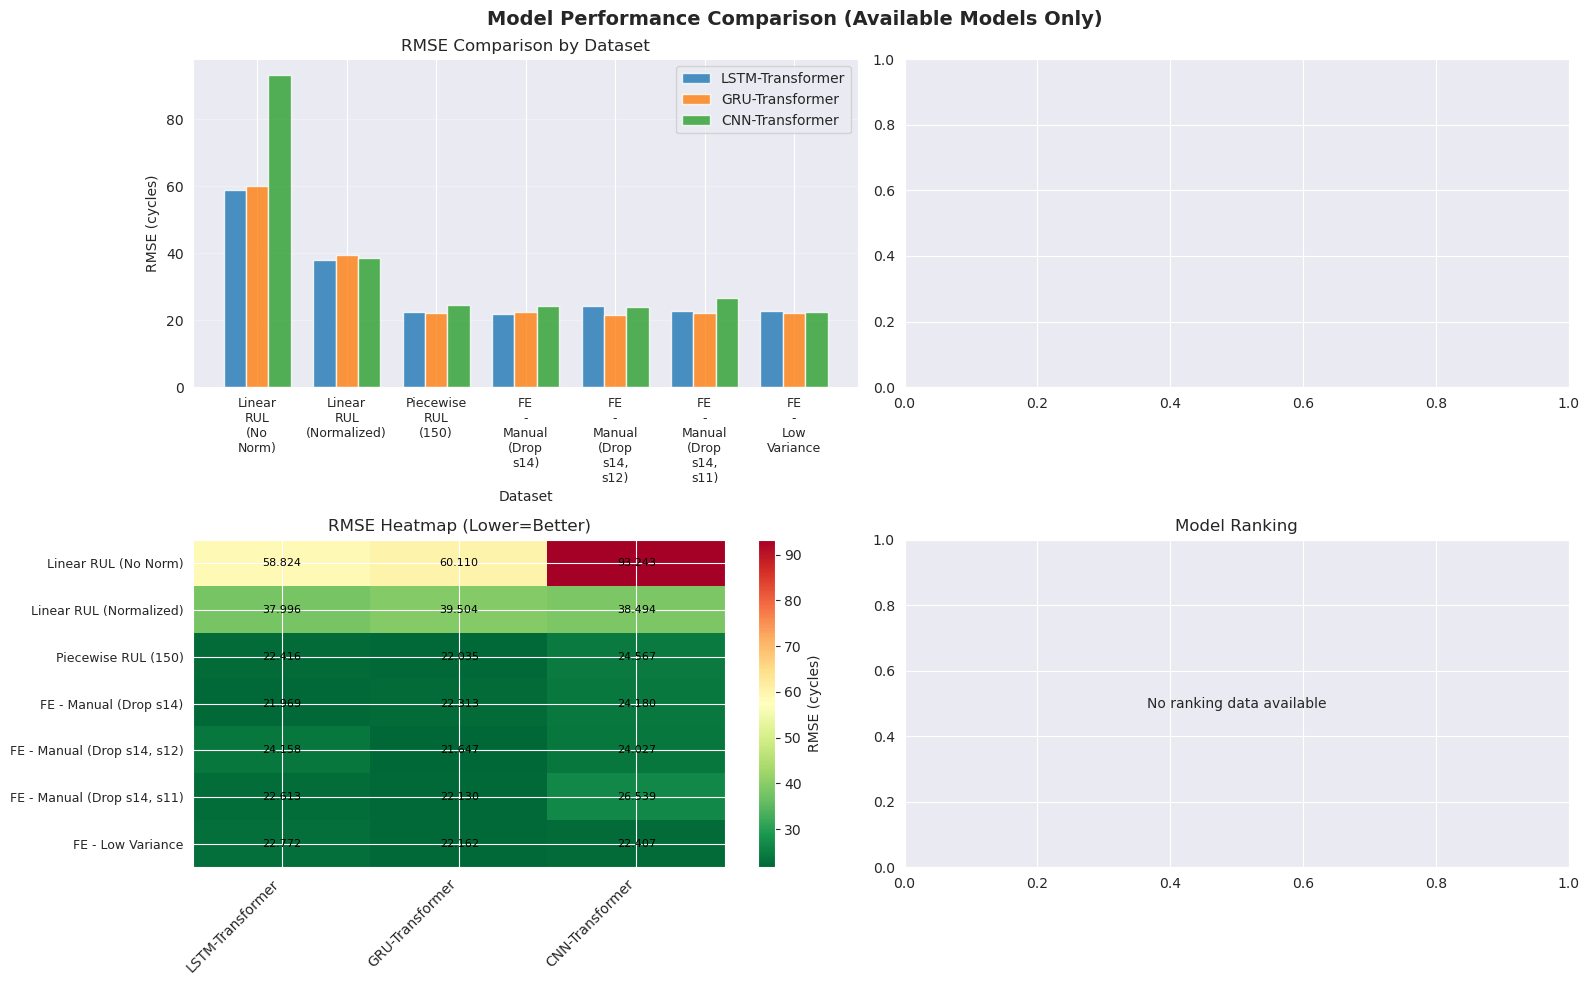

In [33]:
# ============ VISUALIZATION: MINIMAL COMPARISON PLOTS (WITH FAILSAFE) ============

def build_evaluation_data(test_results_all, dataset_names, model_names_list):
    """
    Safely build evaluation data, only including models that were successfully evaluated.
    Returns available datasets and models, plus their metrics.
    """
    # Find available models and datasets from actual results
    available_models = set()
    available_datasets = set()
    
    for (dataset_name, model_name) in test_results_all.keys():
        available_models.add(model_name)
        available_datasets.add(dataset_name)
    
    # Filter to use only available combinations
    available_models = [m for m in model_names_list if m in available_models]
    available_datasets = [d for d in dataset_names if d in available_datasets]
    
    if not available_models or not available_datasets:
        print("⚠️  No successful model evaluations found!")
        return None
    
    print(f"✅ Found {len(available_models)} available models and {len(available_datasets)} available datasets")
    print(f"   Models: {', '.join(available_models)}")
    print(f"   Datasets: {', '.join(available_datasets)}")
    
    # Build metrics dictionaries only for available combinations
    rmse_by_model_dataset = {}
    
    for model_name in available_models:
        rmse_by_model_dataset[model_name] = []
        
        for dataset_name in available_datasets:
            key = (dataset_name, model_name)
            
            # Only add if this combination exists
            if key in test_results_all:
                rmse_by_model_dataset[model_name].append(test_results_all[key]['test_rmse'])
            else:
                # Skip missing combinations (will be shown as gaps)
                pass
    
    return {
        'rmse_by_model_dataset': rmse_by_model_dataset,
        'available_models': available_models,
        'available_datasets': available_datasets
    }

# ============ BUILD AND VALIDATE EVALUATION DATA ============
flat_results = {}
for (seed, dataset_name, model_name), metrics in test_results_all.items():
    flat_results[(dataset_name, model_name)] = metrics

eval_data = build_evaluation_data(flat_results, dataset_names, model_names_list)

if eval_data is None:
    print("\n❌ Cannot create visualization - no successful model evaluations")
else:
    # Extract data
    rmse_by_model_dataset = eval_data['rmse_by_model_dataset']
    available_models = eval_data['available_models']
    available_datasets = eval_data['available_datasets']
    
    # Create compact 2x2 comparison plots
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Model Performance Comparison (Available Models Only)', fontsize=14, fontweight='bold')
    
    # 1. RMSE comparison - grouped by model
    x = np.arange(len(available_datasets))
    width = 0.25 if len(available_models) > 1 else 0.4
    
    for idx, model_name in enumerate(available_models):
        axes[0, 0].bar(x + idx*width, rmse_by_model_dataset[model_name], width, label=model_name, alpha=0.8)
    
    axes[0, 0].set_xlabel('Dataset')
    axes[0, 0].set_ylabel('RMSE (cycles)')
    axes[0, 0].set_title('RMSE Comparison by Dataset')
    axes[0, 0].set_xticks(x + width * (len(available_models) - 1) / 2)
    axes[0, 0].set_xticklabels([d.replace(' ', '\n') for d in available_datasets], fontsize=9)
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # 3. RMSE heatmap
    rmse_matrix = np.array([[rmse_by_model_dataset[m][i] for m in available_models] for i in range(len(available_datasets))])
    im = axes[1, 0].imshow(rmse_matrix, cmap='RdYlGn_r', aspect='auto')
    axes[1, 0].set_xticks(np.arange(len(available_models)))
    axes[1, 0].set_yticks(np.arange(len(available_datasets)))
    axes[1, 0].set_xticklabels(available_models, rotation=45, ha='right')
    axes[1, 0].set_yticklabels(available_datasets, fontsize=9)
    axes[1, 0].set_title('RMSE Heatmap (Lower=Better)')
    
    # Add values to heatmap
    for i in range(len(available_datasets)):
        for j in range(len(available_models)):
            text = axes[1, 0].text(j, i, f'{rmse_matrix[i, j]:.3f}',
                                    ha="center", va="center", color="black", fontsize=8)
    
    plt.colorbar(im, ax=axes[1, 0], label='RMSE (cycles)')
    
    # 4. Model performance ranking
    model_avg_rmse = {}
    for model_name in available_models:
        rmse_list = [test_results_all[(dataset_name, model_name)]['test_rmse'] 
                     for dataset_name in available_datasets 
                     if (dataset_name, model_name) in test_results_all]
        
        if rmse_list:  # Only include if has results
            model_avg_rmse[model_name] = np.mean(rmse_list)
    
    if model_avg_rmse:
        sorted_models = sorted(model_avg_rmse.items(), key=lambda x: x[1])
        model_names_sorted = [m[0] for m in sorted_models]
        rmse_sorted = [m[1] for m in sorted_models]
        colors_rank = ['#2ecc71', '#3498db', '#e74c3c'][:len(sorted_models)]
        
        axes[1, 1].barh(model_names_sorted, rmse_sorted, color=colors_rank, alpha=0.8)
        axes[1, 1].set_xlabel('Average RMSE (cycles)')
        axes[1, 1].set_title('Model Ranking (Lower RMSE = Better)')
        axes[1, 1].grid(True, alpha=0.3, axis='x')
        
        for i, v in enumerate(rmse_sorted):
            axes[1, 1].text(v + 0.1, i, f'{v:.4f}', va='center', fontsize=9)
    else:
        axes[1, 1].text(0.5, 0.5, 'No ranking data available', ha='center', va='center')
        axes[1, 1].set_title('Model Ranking')
    
    plt.tight_layout()
    plt.show()
    